# <div style="background-color:rgba(204, 229, 255, 0.5); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(0, 76, 153, 1);">PHYS 232 - BlackBody Radiation - Day 1<span style="color:red"></span></span></div>





In [ ]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Add paths to find PHYS231
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '/home/jovyan/PHYS232')  # UBC JupyterLab path
sys.path.insert(0, 'C:\\Users\\gdoer\\Documents\\Github Repos\\phys232-labs')  # Windows path

# Import PHYS231 and run the installer
import PHYS231
PHYS231.Installer()

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys

: 

In [ ]:
T = np.arange(100, 1211, 1, dtype=float)

E_mV = np.array([
    # 100–190 °C
    4.096, 4.138, 4.179, 4.220, 4.262, 4.303, 4.344, 4.385, 4.427, 4.468, 4.509,
    4.509, 4.550, 4.591, 4.633, 4.674, 4.715, 4.756, 4.797, 4.838, 4.879, 4.920,
    4.920, 4.961, 5.002, 5.043, 5.084, 5.124, 5.165, 5.206, 5.247, 5.288, 5.328,
    5.328, 5.369, 5.410, 5.450, 5.491, 5.532, 5.572, 5.613, 5.653, 5.694, 5.735,
    5.735, 5.775, 5.815, 5.856, 5.896, 5.937, 5.977, 6.017, 6.058, 6.098, 6.138,
    6.138, 6.179, 6.219, 6.259, 6.299, 6.339, 6.380, 6.420, 6.460, 6.500, 6.540,
    6.540, 6.580, 6.620, 6.660, 6.701, 6.741, 6.781, 6.821, 6.861, 6.901, 6.941,
    6.941, 6.981, 7.021, 7.060, 7.100, 7.140, 7.180, 7.220, 7.260, 7.300, 7.340,
    7.340, 7.380, 7.420, 7.460, 7.500, 7.540, 7.579, 7.619, 7.659, 7.699, 7.739,
    7.739, 7.779, 7.819, 7.859, 7.899, 7.939, 7.979, 8.019, 8.059, 8.099, 8.138,
    8.138, 8.178, 8.218, 8.258, 8.298, 8.338, 8.378, 8.418, 8.458, 8.499, 8.539,
    8.539, 8.579, 8.619, 8.659, 8.699, 8.739, 8.779, 8.819, 8.860, 8.900, 8.940,
    8.940, 8.980, 9.020, 9.061, 9.101, 9.141, 9.181, 9.222, 9.262, 9.302, 9.343,
    9.343, 9.383, 9.423, 9.464, 9.504, 9.545, 9.585, 9.626, 9.666, 9.707, 9.747,
    9.747, 9.788, 9.828, 9.869, 9.909, 9.950, 9.991, 10.031, 10.072, 10.113, 10.153,
    10.153, 10.194, 10.235, 10.276, 10.316, 10.357, 10.398, 10.439, 10.480, 10.520, 10.561,
    10.561, 10.602, 10.643, 10.684, 10.725, 10.766, 10.807, 10.848, 10.889, 10.930, 10.971,
    10.971, 11.012, 11.053, 11.094, 11.135, 11.176, 11.217, 11.259, 11.300, 11.341, 11.382,
    11.382, 11.423, 11.465, 11.506, 11.547, 11.588, 11.630, 11.671, 11.712, 11.753, 11.795,
    11.795, 11.836, 11.877, 11.919, 11.960, 12.001, 12.043, 12.084, 12.126, 12.167, 12.209,

    # 300–390 °C
    12.209, 12.250, 12.291, 12.333, 12.374, 12.416, 12.457, 12.499, 12.540, 12.582, 12.624,
    12.624, 12.665, 12.707, 12.748, 12.790, 12.831, 12.873, 12.915, 12.956, 12.998, 13.040,
    13.040, 13.081, 13.123, 13.165, 13.206, 13.248, 13.290, 13.331, 13.373, 13.415, 13.457,
    13.457, 13.498, 13.540, 13.582, 13.624, 13.665, 13.707, 13.749, 13.791, 13.833, 13.874,
    13.874, 13.916, 13.958, 14.000, 14.042, 14.084, 14.126, 14.167, 14.209, 14.251, 14.293,
    14.293, 14.335, 14.377, 14.419, 14.461, 14.503, 14.545, 14.587, 14.629, 14.671, 14.713,
    14.713, 14.755, 14.797, 14.839, 14.881, 14.923, 14.965, 15.007, 15.049, 15.091, 15.133,
    15.133, 15.175, 15.217, 15.259, 15.301, 15.343, 15.385, 15.427, 15.469, 15.511, 15.554,
    15.554, 15.596, 15.638, 15.680, 15.722, 15.764, 15.806, 15.849, 15.891, 15.933, 15.975,

    # 400–490 °C
    15.975, 16.017, 16.059, 16.102, 16.144, 16.186, 16.228, 16.270, 16.313, 16.355, 16.397,
    16.397, 16.439, 16.482, 16.524, 16.566, 16.608, 16.651, 16.693, 16.735, 16.778, 16.820,
    16.820, 16.862, 16.904, 16.947, 16.989, 17.031, 17.074, 17.116, 17.158, 17.201, 17.243,
    17.243, 17.285, 17.328, 17.370, 17.413, 17.455, 17.497, 17.540, 17.582, 17.624, 17.667,
    17.667, 17.709, 17.752, 17.794, 17.837, 17.879, 17.921, 17.964, 18.006, 18.049, 18.091,
    18.091, 18.134, 18.176, 18.218, 18.261, 18.303, 18.346, 18.388, 18.431, 18.473, 18.516,
    18.516, 18.558, 18.601, 18.643, 18.686, 18.728, 18.771, 18.813, 18.856, 18.898, 18.941,
    18.941, 18.983, 19.026, 19.068, 19.111, 19.154, 19.196, 19.239, 19.281, 19.324, 19.366,
    19.366, 19.409, 19.451, 19.494, 19.537, 19.579, 19.622, 19.664, 19.707, 19.750, 19.792,

    # 500–590 °C
    19.792, 19.835, 19.877, 19.920, 19.962, 20.005, 20.048, 20.090, 20.133, 20.175, 20.218,
    20.218, 20.261, 20.303, 20.346, 20.389, 20.431, 20.474, 20.516, 20.559, 20.602, 20.644,
    20.644, 20.687, 20.730, 20.772, 20.815, 20.857, 20.900, 20.943, 20.985, 21.028, 21.071,
    21.071, 21.113, 21.156, 21.199, 21.241, 21.284, 21.326, 21.369, 21.412, 21.454, 21.497,
    21.497, 21.540, 21.582, 21.625, 21.668, 21.710, 21.753, 21.796, 21.838, 21.881, 21.924,
    21.924, 21.966, 22.009, 22.052, 22.094, 22.137, 22.179, 22.222, 22.265, 22.307, 22.350,
    22.350, 22.393, 22.435, 22.478, 22.521, 22.563, 22.606, 22.649, 22.691, 22.734, 22.776,
    22.776, 22.819, 22.862, 22.904, 22.947, 22.990, 23.032, 23.075, 23.117, 23.160, 23.203,
    23.203, 23.245, 23.288, 23.331, 23.373, 23.416, 23.458, 23.501, 23.544, 23.586, 23.629,

    # 600–690 °C
    23.629, 23.671, 23.714, 23.757, 23.799, 23.842, 23.884, 23.927, 23.970, 24.012, 24.055,
    24.055, 24.097, 24.140, 24.182, 24.225, 24.267, 24.310, 24.353, 24.395, 24.438, 24.480,
    24.480, 24.523, 24.565, 24.608, 24.650, 24.693, 24.735, 24.778, 24.820, 24.863, 24.905,
    24.905, 24.948, 24.990, 25.033, 25.075, 25.118, 25.160, 25.203, 25.245, 25.288, 25.330,
    25.330, 25.373, 25.415, 25.458, 25.500, 25.543, 25.585, 25.627, 25.670, 25.712, 25.755,
    25.755, 25.797, 25.840, 25.882, 25.924, 25.967, 26.009, 26.052, 26.094, 26.136, 26.179,
    26.179, 26.221, 26.263, 26.306, 26.348, 26.390, 26.433, 26.475, 26.517, 26.560, 26.602,
    26.602, 26.644, 26.687, 26.729, 26.771, 26.814, 26.856, 26.898, 26.940, 26.983, 27.025,
    27.025, 27.067, 27.109, 27.152, 27.194, 27.236, 27.278, 27.320, 27.363, 27.405, 27.447,

    # 700–790 °C
    27.447, 27.489, 27.531, 27.574, 27.616, 27.658, 27.700, 27.742, 27.784, 27.826, 27.869,
    27.869, 27.911, 27.953, 27.995, 28.037, 28.079, 28.121, 28.163, 28.205, 28.247, 28.289,
    28.289, 28.332, 28.374, 28.416, 28.458, 28.500, 28.542, 28.584, 28.626, 28.668, 28.710,
    28.710, 28.752, 28.794, 28.835, 28.877, 28.919, 28.961, 29.003, 29.045, 29.087, 29.129,
    29.129, 29.171, 29.213, 29.255, 29.297, 29.338, 29.380, 29.422, 29.464, 29.506, 29.548,
    29.548, 29.589, 29.631, 29.673, 29.715, 29.757, 29.798, 29.840, 29.882, 29.924, 29.965,
    29.965, 30.007, 30.049, 30.090, 30.132, 30.174, 30.216, 30.257, 30.299, 30.341, 30.382,
    30.382, 30.424, 30.466, 30.507, 30.549, 30.590, 30.632, 30.674, 30.715, 30.757, 30.798,
    30.798, 30.840, 30.881, 30.923, 30.964, 31.006, 31.047, 31.089, 31.130, 31.172, 31.213,

    # 800–890 °C
    31.213, 31.255, 31.296, 31.338, 31.379, 31.421, 31.462, 31.504, 31.545, 31.586, 31.628,
    31.628, 31.669, 31.710, 31.752, 31.793, 31.834, 31.876, 31.917, 31.958, 32.000, 32.041,
    32.041, 32.082, 32.124, 32.165, 32.206, 32.247, 32.289, 32.330, 32.371, 32.412, 32.453,
    32.453, 32.495, 32.536, 32.577, 32.618, 32.659, 32.700, 32.742, 32.783, 32.824, 32.865,
    32.865, 32.906, 32.947, 32.988, 33.029, 33.070, 33.111, 33.152, 33.193, 33.234, 33.275,
    33.275, 33.316, 33.357, 33.398, 33.439, 33.480, 33.521, 33.562, 33.603, 33.644, 33.685,
    33.685, 33.726, 33.767, 33.808, 33.848, 33.889, 33.930, 33.971, 34.012, 34.053, 34.093,
    34.093, 34.134, 34.175, 34.216, 34.257, 34.297, 34.338, 34.379, 34.420, 34.460, 34.501,
    34.501, 34.542, 34.582, 34.623, 34.664, 34.704, 34.745, 34.786, 34.826, 34.867, 34.908,

    # 900–990 °C
    34.908, 34.948, 34.989, 35.029, 35.070, 35.110, 35.151, 35.192, 35.232, 35.273, 35.313,
    35.313, 35.354, 35.394, 35.435, 35.475, 35.516, 35.556, 35.596, 35.637, 35.677, 35.718,
    35.718, 35.758, 35.798, 35.839, 35.879, 35.920, 35.960, 36.000, 36.041, 36.081, 36.121,
    36.121, 36.162, 36.202, 36.242, 36.282, 36.323, 36.363, 36.403, 36.443, 36.484, 36.524,
    36.524, 36.564, 36.604, 36.644, 36.685, 36.725, 36.765, 36.805, 36.845, 36.885, 36.925,
    36.925, 36.965, 37.006, 37.046, 37.086, 37.126, 37.166, 37.206, 37.246, 37.286, 37.326,
    37.326, 37.366, 37.406, 37.446, 37.486, 37.526, 37.566, 37.606, 37.646, 37.686, 37.725,
    37.725, 37.765, 37.805, 37.845, 37.885, 37.925, 37.965, 38.005, 38.044, 38.084, 38.124,
    38.124, 38.164, 38.204, 38.243, 38.283, 38.323, 38.363, 38.402, 38.442, 38.482, 38.522,

    # 1000–1100 °C
    38.522, 38.561, 38.601, 38.641, 38.680, 38.720, 38.760, 38.799, 38.839, 38.878, 38.918,
    38.918, 38.958, 38.997, 39.037, 39.076, 39.116, 39.155, 39.195, 39.235, 39.274, 39.314,
    39.314, 39.353, 39.393, 39.432, 39.471, 39.511, 39.550, 39.590, 39.629, 39.669, 39.708,
    39.708, 39.747, 39.787, 39.826, 39.866, 39.905, 39.944, 39.984, 40.023, 40.062, 40.101,
    40.101, 40.141, 40.180, 40.219, 40.259, 40.298, 40.337, 40.376, 40.415, 40.455, 40.494,
    40.494, 40.533, 40.572, 40.611, 40.651, 40.690, 40.729, 40.768, 40.807, 40.846, 40.885,
    40.885, 40.924, 40.963, 41.002, 41.042, 41.081, 41.120, 41.159, 41.198, 41.237, 41.276,
    41.276, 41.315, 41.354, 41.393, 41.431, 41.470, 41.509, 41.548, 41.587, 41.626, 41.665,
    41.665, 41.704, 41.743, 41.781, 41.820, 41.859, 41.898, 41.937, 41.976, 42.014, 42.053,
    42.053, 42.092, 42.131, 42.169, 42.208, 42.247, 42.286, 42.324, 42.363, 42.402, 42.440,
    42.440, 42.479, 42.518, 42.556, 42.595, 42.633, 42.672, 42.711, 42.749, 42.788, 42.826,
    42.826, 42.865, 42.903, 42.942, 42.980, 43.019, 43.057, 43.096, 43.134, 43.173, 43.211,
    43.211, 43.250, 43.288, 43.327, 43.365, 43.403, 43.442, 43.480, 43.518, 43.557, 43.595,
    43.595, 43.633, 43.672, 43.710, 43.748, 43.787, 43.825, 43.863, 43.901, 43.940, 43.978,
    43.978, 44.016, 44.054, 44.092, 44.130, 44.169, 44.207, 44.245, 44.283, 44.321, 44.359,
    44.359, 44.397, 44.435, 44.473, 44.512, 44.550, 44.588, 44.626, 44.664, 44.702, 44.740,
    44.740, 44.778, 44.816, 44.853, 44.891, 44.929, 44.967, 45.005, 45.043, 45.081, 45.119,
    45.119, 45.157, 45.194, 45.232, 45.270, 45.308, 45.346, 45.383, 45.421, 45.459, 45.497
], dtype=float)





: 

In [ ]:
df1 = pd.DataFrame({"Temp": T,
                   "E_mV": E_mV})

# Display DataFrame
df1

: 

In [ ]:
PHYS231.Scatter(
    xData = T,
    yData = E_mV,
    xlabel = "Temp",
    ylabel = "Voltage",
    xUnits = "C",
    yUnits = "mV"
);

: 

In [ ]:
PHYS231.LinearFit(xData = T, 
                yData = E_mV, 
                xlabel = 'Capacitor Voltage', 
                ylabel = 'Charge', 
                xUnits = 'V', 
                yUnits = 'C'
                );

: 

In [ ]:
coeffs = np.polyfit(E_mV, T, deg=2)  
print(coeffs)

: 

In [132]:
df = pd.read_csv("temp_log3.csv")

s = df["V_tc"].astype(str).str.replace('"', '', regex=False)

split = s.str.split(expand=True)

split.columns = ["time", "V_tc"]
split["time"] = pd.to_numeric(split["time"])
split["V_tc"] = pd.to_numeric(split["V_tc"])

split.to_csv("temp_log3_split.csv", index=False)


In [133]:
temp_df = pd.read_csv("temp_log3_split.csv")   
I_750 = pd.read_csv("Intensities.csv", usecols=["time", "I_750"])             
I_800 = pd.read_csv("Intensities.csv", usecols=["time", 'I_800'])       
I_850 = pd.read_csv("Intensities.csv", usecols=['time', 'I_850'])       
I_900 = pd.read_csv("Intensities.csv", usecols=["time", 'I_900'])       

temp_df["V_tc"] = temp_df["V_tc"]*1000

temp_df


## Reads all the csv files

,time,V_tc
0,15.000778,15.379766
1,30.000873,15.753378
2,45.000232,16.131441
3,60.000876,16.488414
4,75.000935,16.820555
...,...,...
286,4304.987500,37.181046
287,4319.986900,37.224419
288,4334.986800,37.261777
289,4349.987100,37.298488


In [ ]:
a2, a1, a0 = 1.87459883e-02, 2.55753136e+01, 1.23996072e+00
def T_from_V(V):
    T_C = (V-0.291)/0.037719
    return T_C # °C

temp_df["T_C"] = T_from_V(temp_df["V_tc"])
temp_df["T_K"] = temp_df["T_C"] + 273.15

##This adds columns for Kelvin and Celcius

print(len(temp_df), len(I_750))

I_750

291 292


,time,I_750
0,0.0,0.003498
1,15.0,0.003533
2,30.0,0.003478
3,45.0,0.003508
4,60.0,0.003610
...,...,...
287,4305.0,0.961551
288,4320.0,0.963005
289,4335.0,0.963075
290,4350.0,0.963107


In [ ]:
def merge_temp_intensity(temp_df, I_df):
    I_df['T_C']= temp_df['T_C']
    I_df['T_K']= temp_df['T_K']
    return I_df

df_750 = merge_temp_intensity(temp_df, I_750)
df_800 = merge_temp_intensity(temp_df, I_800)
df_850 = merge_temp_intensity(temp_df, I_850)
df_900 = merge_temp_intensity(temp_df, I_900)

## This merges the temperature log with the Intensity measurments
df_750

,time,I_750,T_C,T_K
0,0.0,0.003498,400.030913,673.180913
1,15.0,0.003533,409.936053,683.086053
2,30.0,0.003478,419.959198,693.109198
3,45.0,0.003508,429.423208,702.573208
4,60.0,0.003610,438.228877,711.378877
...,...,...,...,...
287,4305.0,0.961551,979.172804,1252.322804
288,4320.0,0.963005,980.163233,1253.313233
289,4335.0,0.963075,981.136509,1254.286509
290,4350.0,0.963107,982.156552,1255.306552


In [ ]:
def prep_lnI_vs_invT(df):
    df = df.copy()
    df = df[df.iloc[:, 1] > 0]  # avoid log of zero
    df["ln_I"] = np.log(df.iloc[:, 1])
    df["inv_T"] = 1.0 / df["T_K"]
    return df

df_750_pp = prep_lnI_vs_invT(df_750)
df_800_pp = prep_lnI_vs_invT(df_800)
df_850_pp = prep_lnI_vs_invT(df_850)
df_900_pp = prep_lnI_vs_invT(df_900)

## This creates the Natural log versions of the dataframe




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_lnI_vs_invT(df_750_pp, df_800_pp, df_850_pp, df_900_pp, title):
    plt.figure(figsize=(8, 6))

    x750 = df_750_pp["inv_T"].values
    y750 = df_750_pp["ln_I"].values
    m750, b750 = np.polyfit(x750, y750, 1)
    plt.scatter(x750, y750, marker='s', color='C0', s=1, label='750 nm data')
    xx = np.linspace(x750.min(), x750.max(), 100)
    plt.plot(xx, m750*xx + b750, linestyle='-', color='C0', linewidth=2.5, label='750 nm fit')

    x800 = df_800_pp["inv_T"].values
    y800 = df_800_pp["ln_I"].values
    m800, b800 = np.polyfit(x800, y800, 1)
    plt.scatter(x800, y800, marker='o', color='C1', s=1, label='800 nm data')
    xx = np.linspace(x800.min(), x800.max(), 100)
    plt.plot(xx, m800*xx + b800, linestyle='--', color='C1', linewidth=2.5, label='800 nm fit')

    x850 = df_850_pp["inv_T"].values
    y850 = df_850_pp["ln_I"].values
    m850, b850 = np.polyfit(x850, y850, 1)
    plt.scatter(x850, y850, marker='^', color='C2', s=1, label='850 nm data')
    xx = np.linspace(x850.min(), x850.max(), 100)
    plt.plot(xx, m850*xx + b850, linestyle=':', color='C2', linewidth=2.5, label='850 nm fit')

    x900 = df_900_pp["inv_T"].values
    y900 = df_900_pp["ln_I"].values
    m900, b900 = np.polyfit(x900, y900, 1)
    plt.scatter(x900, y900, marker='D', color='C3', s=1, label='900 nm data')
    xx = np.linspace(x900.min(), x900.max(), 100)
    plt.plot(xx, m900*xx + b900, linestyle='-.', color='C3', linewidth=2.5, label='900 nm fit')

    plt.xlabel("1/T (K$^{-1}$)")
    plt.ylabel("ln I")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return (m750, b750), (m800, b800), (m850, b850), (m900, b900)


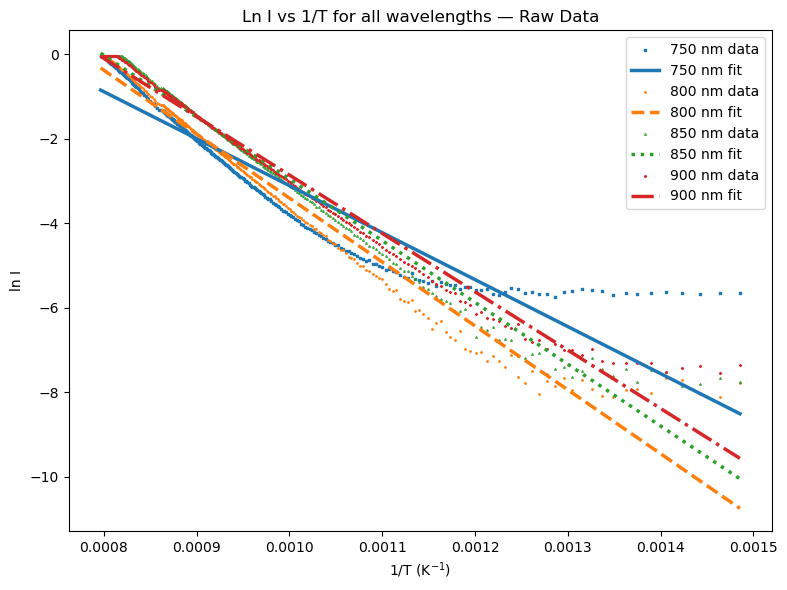

In [ ]:
(m750, b750), (m800, b800), (m850, b850), (m900, b900) = plot_all_lnI_vs_invT(
    df_750_pp,
    df_800_pp,
    df_850_pp,
    df_900_pp,
    "Ln I vs 1/T for all wavelengths — Raw Data"
)

In [ ]:
df_750_pp = df_750_pp[df_750_pp.index>=100]
df_800_pp = df_800_pp[df_800_pp.index>=45]
df_850_pp = df_850_pp[df_850_pp.index>=95]
df_900_pp = df_900_pp[df_900_pp.index>=52]

df_750_pp = df_750_pp[df_750_pp.index<=288]
df_800_pp = df_800_pp[df_800_pp.index<=285]
df_850_pp = df_850_pp[df_850_pp.index<=262]
df_900_pp = df_900_pp[df_900_pp.index<=267]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_lnI_vs_invT(df_750_pp, df_800_pp, df_850_pp, df_900_pp, title):
    plt.figure(figsize=(8, 6))

    x750 = df_750_pp["inv_T"].values
    y750 = df_750_pp["ln_I"].values
    m750, b750 = np.polyfit(x750, y750, 1)
    plt.scatter(x750, y750, marker='s', color='C0', s=1, label='750 nm data')
    xx = np.linspace(x750.min(), x750.max(), 100)
    plt.plot(xx, m750*xx + b750, linestyle='-', color='C0', linewidth=2.5, label='750 nm fit')

    x800 = df_800_pp["inv_T"].values
    y800 = df_800_pp["ln_I"].values
    m800, b800 = np.polyfit(x800, y800, 1)
    plt.scatter(x800, y800, marker='o', color='C1', s=1, label='800 nm data')
    xx = np.linspace(x800.min(), x800.max(), 100)
    plt.plot(xx, m800*xx + b800, linestyle='--', color='C1', linewidth=2.5, label='800 nm fit')

    x850 = df_850_pp["inv_T"].values
    y850 = df_850_pp["ln_I"].values
    m850, b850 = np.polyfit(x850, y850, 1)
    plt.scatter(x850, y850, marker='^', color='C2', s=1, label='850 nm data')
    xx = np.linspace(x850.min(), x850.max(), 100)
    plt.plot(xx, m850*xx + b850, linestyle=':', color='C2', linewidth=2.5, label='850 nm fit')

    x900 = df_900_pp["inv_T"].values
    y900 = df_900_pp["ln_I"].values
    m900, b900 = np.polyfit(x900, y900, 1)
    plt.scatter(x900, y900, marker='D', color='C3', s=1, label='900 nm data')
    xx = np.linspace(x900.min(), x900.max(), 100)
    plt.plot(xx, m900*xx + b900, linestyle='-.', color='C3', linewidth=2.5, label='900 nm fit')

    plt.xlabel("1/T (K$^{-1}$)")
    plt.ylabel("ln I")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return (m750, b750), (m800, b800), (m850, b850), (m900, b900)


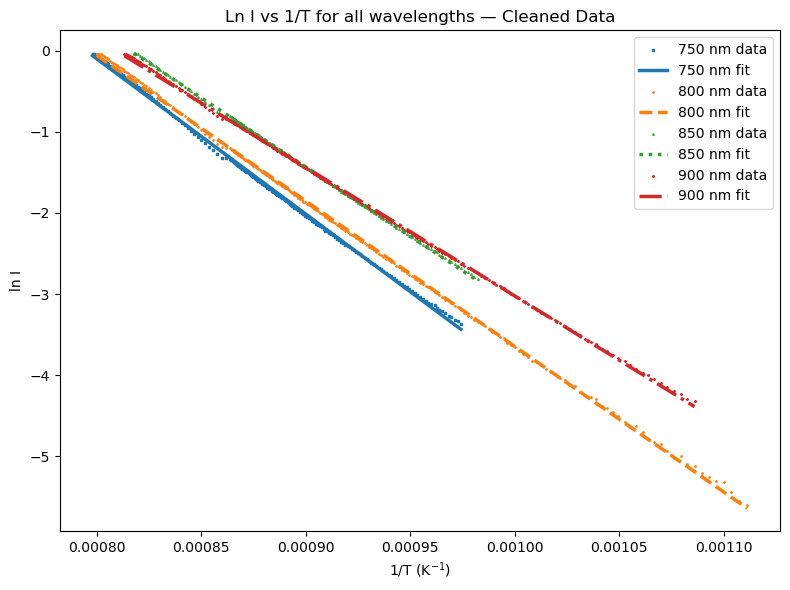

In [ ]:
(m750, b750), (m800, b800), (m850, b850), (m900, b900) = plot_all_lnI_vs_invT(
    df_750_pp,
    df_800_pp,
    df_850_pp,
    df_900_pp,
    "Ln I vs 1/T for all wavelengths — Cleaned Data"
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_lnI_vs_invT(df_750_pp, df_800_pp, df_850_pp, df_900_pp, title):
    plt.figure(figsize=(8, 6))

    # 750 nm
    x750 = df_750_pp["inv_T"].values
    y750 = df_750_pp["ln_I"].values
    (m750, b750), cov750 = np.polyfit(x750, y750, 1, cov=True)
    dm750 = np.sqrt(cov750[0, 0])
    plt.scatter(x750, y750, marker='s', color='C0', s=1, label='750 nm data')
    xx = np.linspace(x750.min(), x750.max(), 100)
    plt.plot(xx, m750*xx + b750, linestyle='-', color='C0', linewidth=2.5, label='750 nm fit')

    # 800 nm
    x800 = df_800_pp["inv_T"].values
    y800 = df_800_pp["ln_I"].values
    (m800, b800), cov800 = np.polyfit(x800, y800, 1, cov=True)
    dm800 = np.sqrt(cov800[0, 0])
    plt.scatter(x800, y800, marker='o', color='C1', s=1, label='800 nm data')
    xx = np.linspace(x800.min(), x800.max(), 100)
    plt.plot(xx, m800*xx + b800, linestyle='--', color='C1', linewidth=2.5, label='800 nm fit')

    # 850 nm
    x850 = df_850_pp["inv_T"].values
    y850 = df_850_pp["ln_I"].values
    (m850, b850), cov850 = np.polyfit(x850, y850, 1, cov=True)
    dm850 = np.sqrt(cov850[0, 0])
    plt.scatter(x850, y850, marker='^', color='C2', s=1, label='850 nm data')
    xx = np.linspace(x850.min(), x850.max(), 100)
    plt.plot(xx, m850*xx + b850, linestyle=':', color='C2', linewidth=2.5, label='850 nm fit')

    # 900 nm
    x900 = df_900_pp["inv_T"].values
    y900 = df_900_pp["ln_I"].values
    (m900, b900), cov900 = np.polyfit(x900, y900, 1, cov=True)
    dm900 = np.sqrt(cov900[0, 0])
    plt.scatter(x900, y900, marker='D', color='C3', s=1, label='900 nm data')
    xx = np.linspace(x900.min(), x900.max(), 100)
    plt.plot(xx, m900*xx + b900, linestyle='-.', color='C3', linewidth=2.5, label='900 nm fit')

    plt.xlabel("1/T (K$^{-1}$)")
    plt.ylabel("ln I")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return (m750, dm750, b750), (m800, dm800, b800), (m850, dm850, b850), (m900, dm900, b900)


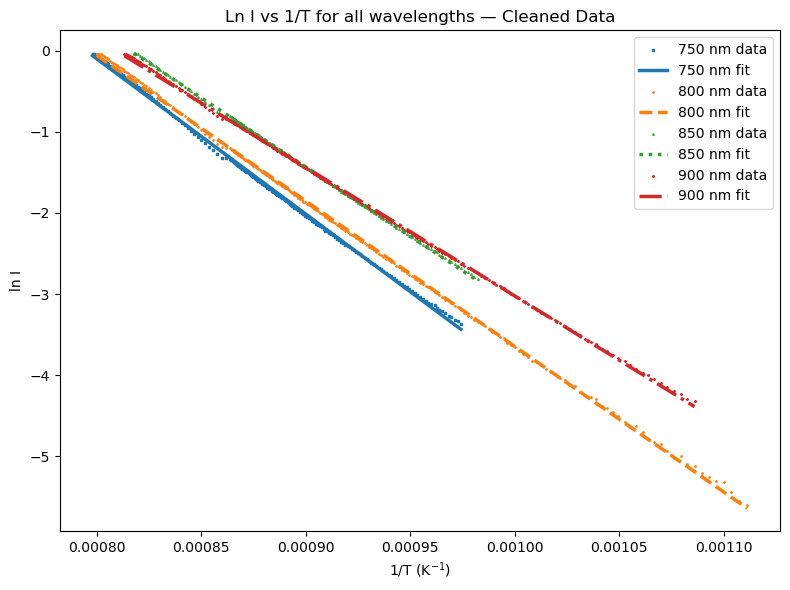

In [ ]:
(m750, dm750, b750), (m800, dm800, b800), (m850, dm850, b850), (m900, dm900, b900) = \
    plot_all_lnI_vs_invT(df_750_pp, df_800_pp, df_850_pp, df_900_pp,
                         "Ln I vs 1/T for all wavelengths — Cleaned Data")


In [ ]:
c     = 299792458
k_B   = 1.380649e-23
h_true = 6.62607015e-34

def report_h_from_slope(label, m, dm, lambda_nm):
    lam = lambda_nm * 1e-9
    h   = -m  * lam * k_B / c
    dh  = dm * lam * k_B / c      # propagated uncertainty
    pct_err = abs(100*(1 - abs(h/h_true)))  # percent error in %

    print(f"Planck's constant from {label}: "
          f"h = {h:.4e} ± {dh:.4e} J·s, "
          f"Percent error = {pct_err:.4f}%")

# example calls (use your dm750, dm800, ... from the fits)
report_h_from_slope("750 nm", m750, dm750, 750)
report_h_from_slope("800 nm", m800, dm800, 800)
report_h_from_slope("850 nm", m850, dm850, 850)
report_h_from_slope("900 nm", m900, dm900, 900)


Planck's constant from 750 nm: h = 6.6100e-34 ± 1.4697e-36 J·s, Percent error = 0.2420%
Planck's constant from 800 nm: h = 6.6081e-34 ± 8.8433e-37 J·s, Percent error = 0.2712%
Planck's constant from 850 nm: h = 6.6774e-34 ± 8.2778e-37 J·s, Percent error = 0.7749%
Planck's constant from 900 nm: h = 6.5704e-34 ± 7.6985e-37 J·s, Percent error = 0.8402%


In [ ]:


# Planck constants (J·s)
h_vals = np.array([
    6.6100e-34,  # 750 nm
    6.6081e-34,  # 800 nm
    6.6774e-34,  # 850 nm
    6.5704e-34   # 900 nm
])

# 1σ uncertainties (J·s)
dh_vals = np.array([
    1.4697e-36,
    8.8433e-37,
    8.2778e-37,
    7.6985e-37
])

# Simple (unweighted) average and standard deviation of the mean
h_mean = np.mean(h_vals)
h_std = np.std(h_vals, ddof=1)        # sample std dev
h_sem = h_std / np.sqrt(len(h_vals))  # standard error of the mean

print(f"Unweighted mean h = {h_mean:.4e} ± {h_sem:.4e} J·s")

# Optional: weighted average using 1/σ² weights
weights = 1 / dh_vals**2
h_wmean = np.average(h_vals, weights=weights)
h_wsem = np.sqrt(1 / np.sum(weights))


PERR = h_wmean / 6.62607015e-34          # ratio to accepted value
percent_error = (1 - PERR) * 100         # signed percent error

print(f"Weighted mean h = {h_wmean:.4e} ± {h_wsem:.4e} J·s")
print(f"Percent error = {percent_error:.4f}%")


Unweighted mean h = 6.6165e-34 ± 2.2261e-36 J·s
Weighted mean h = 6.6160e-34 ± 4.5229e-37 J·s
Percent error = 0.1526%


In [ ]:
c = 299792458       
k_B = 1.380649e-23 
h_true = 6.62607015e-34
def h_from_slope(m, lambda_nm):
    lam = lambda_nm * 1e-9
    return -m * lam * k_B / c

h_750 = h_from_slope(m750, 750)
h_800 = h_from_slope(m800, 800)
h_850 = h_from_slope(m850, 850)
h_900 = h_from_slope(m900, 900)

print(f"Plank's Constant derived from 750nm: {h_750} Percent Error: {1-abs(h_750/h_true)}")
print(f"Plank's Constant derived from 800nm: {h_800} Percent Error: {1-abs(h_800/h_true)}")
print(f"Plank's Constant derived from 850nm: {h_850} Percent Error: {1-abs(h_850/h_true)}")
print(f"Plank's Constant derived from 900nm: {h_900} Percent Error: {1-abs(h_900/h_true)}")

Plank's Constant derived from 750nm: 6.610032911355916e-34 Percent Error: 0.002420324307022881
Plank's Constant derived from 800nm: 6.608099853241897e-34 Percent Error: 0.00271205953925846
Plank's Constant derived from 850nm: 6.677413816184733e-34 Percent Error: -0.00774873567928247
Plank's Constant derived from 900nm: 6.570398747827191e-34 Percent Error: 0.008401873344611177


DAY 2

In [ ]:
lam = pd.read_csv("BBRDay2.csv", usecols=['Wavelength'])       
lam = lam.astype(float)
I_meas = pd.read_csv("BBRDay2.csv", usecols=['Intensity'])  
I_meas = I_meas.astype(float)
lam

,Wavelength
0,350.0
1,351.0
2,352.0
3,353.0
4,354.0
...,...
646,996.0
647,997.0
648,998.0
649,999.0


In [ ]:



lam = lam * 1e-9
lnlam = np.log(lam)
lnI_meas = np.log(I_meas)


y = np.log(I_meas * lam**5)

x = 1/lam

x = np.asarray(x).flatten()
y = np.asarray(y).flatten()


In [ ]:
import numpy as np
import pandas as pd

# Read data
lam = pd.read_csv("BBRDay2.csv", usecols=['Wavelength']).astype(float).values.flatten()
I_meas = pd.read_csv("BBRDay2.csv", usecols=['Intensity']).astype(float).values.flatten()

# Convert wavelength from nm to m
lam = lam * 1e-9

# Build x and y WITHOUT taking log of the product
lnlam = np.log(lam)
lnI_meas = np.log(I_meas)

y = lnI_meas + 5*lnlam   # <-- use this, do NOT recompute y as log(I_meas * lam**5)
x = 1/lam

print("Any NaN in y?", np.any(np.isnan(y)))
print("First 5 y:", y[:5])


Any NaN in y? False
First 5 y: [-82.26170982 -81.99848711 -81.86728544 -81.69374121 -81.72077555]


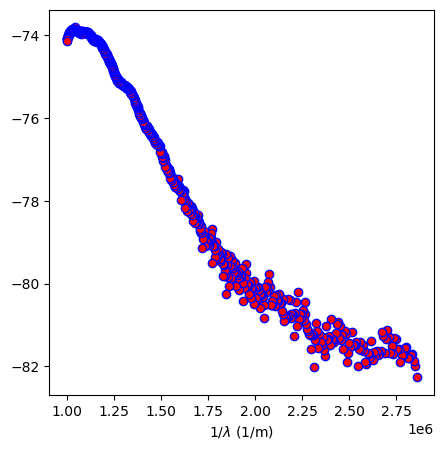

In [ ]:
PHYS231.Scatter(
    xData = x,
    yData = y,
    xlabel = "1/$\lambda$",
    ylabel = "",
    xUnits = "1/m",
    yUnits = ""
);

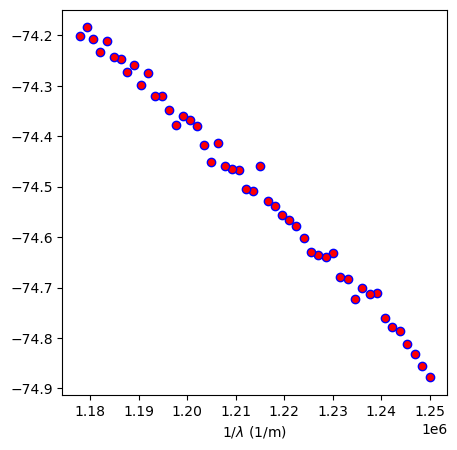

In [18]:
# Enter suitable values for start and stop.
start = 450
stop = 500
x_cut = x[start:stop]
y_cut = y[start:stop]

PHYS231.Scatter(
    xData = x_cut,
    yData = y_cut,
    xlabel = "1/$\lambda$",
    ylabel = "",
    xUnits = "1/m",
    yUnits = ""
);

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(-9.35+/-0.12)e-06,1/1/m
$y$-intercept,$b =$,-63.16+/-0.14,


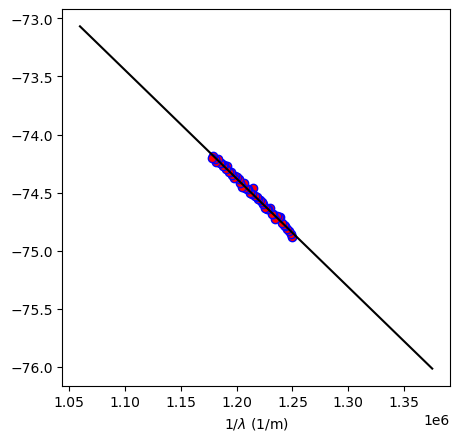

In [19]:
m, b, dm, db, fig3 = PHYS231.LinearFit(
                    xData = x_cut,
                    yData= y_cut,
                    xlabel = "1/$\lambda$",
                    ylabel = "",
                    xUnits = "1/m",
                    yUnits = ""
)

In [20]:
c = 299792458       
k_B = 1.380649e-23 
T = 1104.15

dh = (k_B*T/c)*dm
h  = -(m*k_B*T)/c

h_true = 6.62607015e-34  # accepted Planck's constant
percent_error = abs(h - h_true) / h_true * 100

print(f"Planck's Constant = {h:.4e} +- {dh:.4e}")
print(f"Percent Error = {percent_error:.4f}%")


Planck's Constant = 4.7547e-34 +- 5.9865e-36
Percent Error = 28.2420%
